In [6]:
import pandas as pd

In [10]:
df = pd.read_csv("amazon_reviews_us_Electronics_v1_00.tsv", sep='\t', nrows=10)

In [12]:
df.head()

,marketplace,customer_id,review_id,product_id,product_parent,product_title,product_category,star_rating,helpful_votes,total_votes,vine,verified_purchase,review_headline,review_body,review_date
0,US,41409413,R2MTG1GCZLR2DK,B00428R89M,112201306,yoomall 5M Antenna WIFI RP-SMA Female to Male ...,Electronics,5,0,0,N,Y,Five Stars,As described.,2015-08-31
1,US,49668221,R2HBOEM8LE9928,B000068O48,734576678,"Hosa GPM-103 3.5mm TRS to 1/4"" TRS Adaptor",Electronics,5,0,0,N,Y,It works as advertising.,It works as advertising.,2015-08-31
2,US,12338275,R1P4RW1R9FDPEE,B000GGKOG8,614448099,Channel Master Titan 2 Antenna Preamplifier,Electronics,5,1,1,N,Y,Five Stars,Works pissa,2015-08-31
3,US,38487968,R1EBPM82ENI67M,B000NU4OTA,72265257,LIMTECH Wall charger + USB Hotsync & Charging ...,Electronics,1,0,0,N,Y,One Star,Did not work at all.,2015-08-31
4,US,23732619,R372S58V6D11AT,B00JOQIO6S,308169188,Skullcandy Air Raid Portable Bluetooth Speaker,Electronics,5,1,1,N,Y,Overall pleased with the item,Works well. Bass is somewhat lacking but is pr...,2015-08-31


In [14]:
select = ['product_title', 'star_rating', 'review_headline', 'review_body', 'review_date']

In [16]:
df = pd.read_csv('amazon_reviews_us_Electronics_v1_00.tsv', sep='\t', usecols=select, nrows=50000)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   product_title    50000 non-null  object
 1   star_rating      50000 non-null  int64 
 2   review_headline  50000 non-null  object
 3   review_body      49993 non-null  object
 4   review_date      50000 non-null  object
dtypes: int64(1), object(4)
memory usage: 1.9+ MB


In [20]:
print("Eksik Veri Sayıları:\n")
print(df.isnull().sum())

Eksik Veri Sayıları:

product_title      0
star_rating        0
review_headline    0
review_body        7
review_date        0
dtype: int64


star_rating
5    30732
4     7446
1     5739
3     3413
2     2670
Name: count, dtype: int64


<Axes: title={'center': 'Yıldız Dağılımı'}, xlabel='star_rating'>

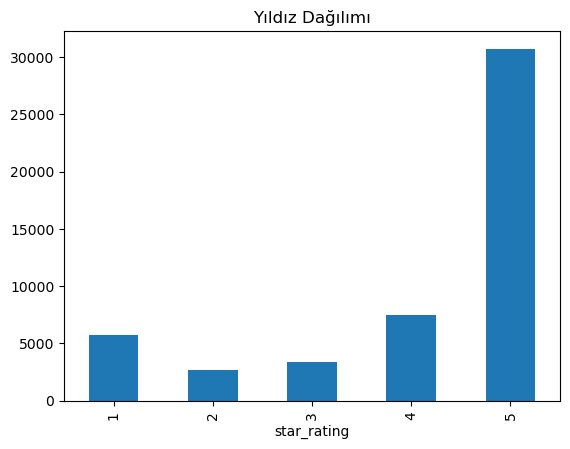

In [22]:
# Hangi puandan kaç tane verilmiş?
print(df['star_rating'].value_counts())

df['star_rating'].value_counts().sort_index().plot(kind='bar', title='Yıldız Dağılımı')

In [24]:
# En çok yorum alan ilk 5 ürün
print(df['product_title'].value_counts().head(5))

product_title
Panasonic ErgoFit In-Ear Earbud Headphone                                                                                                     547
Bluetooth Speaker, DKnight Magicbox Ultra-Portable Wireless Bluetooth Speaker Powerful Sound with build in Microphone, Works for Cellphone    346
AmazonBasics High-Speed HDMI Cable - 6.5 Feet (2 Meters) Supports Ethernet, 3D, 4K and Audio Return                                           345
AmazonBasics High Speed HDMI Cable                                                                                                            226
1byone Amplified HDTV Antenna, with Detachable Amplifier Signal Booster for the Highest Performance and 10 Feet Coaxial Cable-Black           203
Name: count, dtype: int64


In [26]:
# Boş verileri kalıcı olarak (inplace=True) sil
df.dropna(subset=['review_body'], inplace=True)

# Kontrol
print(df.isnull().sum())

product_title      0
star_rating        0
review_headline    0
review_body        0
review_date        0
dtype: int64


In [28]:
# 1. Hepsini küçük harfe çevir
df['cleaned_review'] = df['review_body'].str.lower()

# 2. Noktalama işaretlerini kaldır
df['cleaned_review'] = df['cleaned_review'].str.replace(r'[^\w\s]', '', regex=True)

# Sonucu görelim: Orijinal vs Temizlenmiş
df[['review_body', 'cleaned_review']].head()

,review_body,cleaned_review
0,As described.,as described
1,It works as advertising.,it works as advertising
2,Works pissa,works pissa
3,Did not work at all.,did not work at all
4,Works well. Bass is somewhat lacking but is pr...,works well bass is somewhat lacking but is pre...


In [30]:
def duygu_belirle(puan):
    if puan in [1, 2] :   
        return 'negative'
    elif puan == 3:  
        return 'neutral'
    else:
        return 'positive'

df['sentiment'] = df['star_rating'].apply(duygu_belirle)

In [32]:
df['sentiment'].value_counts()

sentiment
positive    38172
negative     8409
neutral      3412
Name: count, dtype: int64

In [34]:
!pip install textblob

In [36]:
from textblob import TextBlob

In [38]:
# 1. Fonksiyonu tanımlayalım
def get_sentiment_score(text):
    # TextBlob metni okur ve -1 (Negatif) ile +1 (Pozitif) arasında bir puan verir.
    return TextBlob(text).sentiment.polarity

# 2. Fonksiyonu veriye uygulayalım
df['polarity_score'] = df['cleaned_review'].apply(get_sentiment_score)

# 3. Sonuçları karşılaştıralım
# Orijinal Puan (sentiment) vs. Makinenin Hesapladığı Puan (polarity_score)
df[['cleaned_review', 'sentiment', 'polarity_score']].head(10)

,cleaned_review,sentiment,polarity_score
0,as described,positive,0.0000
1,it works as advertising,positive,0.0000
2,works pissa,positive,0.0000
3,did not work at all,negative,0.0000
4,works well bass is somewhat lacking but is pre...,positive,0.0875
5,the quality on these speakers is insanely good...,positive,0.4875
6,wish i could give this product more than five ...,positive,0.5000
7,works great,positive,0.8000
8,great sound and compact battery life seems goo...,positive,0.6750
9,it works well,positive,0.0000


In [40]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [42]:
X = df['cleaned_review']
y = df['sentiment']

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
print("Veri bölündü! Eğitim seti boyutu:", len(X_train))

Veri bölündü! Eğitim seti boyutu: 39994


In [48]:
# 1. Vektörleştirici
vectorizer = TfidfVectorizer(max_features=5000)

# 2. Veriyi Sayıya Çevir (Vektörleştirme)
X_train_vec = vectorizer.fit_transform(X_train)
# Test setine SADECE 'transform' yapıyoruz. (Kopya çekmemesi için!)
X_test_vec = vectorizer.transform(X_test)

# 3. Modeli Kur ve Eğit
model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

# 4. Test Seti Üzerinde Tahmin Yap
y_pred = model.predict(X_test_vec)

# 5. Karneyi Yazdır
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    negative       0.77      0.73      0.75      1691
     neutral       0.44      0.08      0.14       680
    positive       0.90      0.97      0.93      7628

    accuracy                           0.87      9999
   macro avg       0.70      0.60      0.61      9999
weighted avg       0.85      0.87      0.85      9999



In [50]:
# Sadece 'negative' etiketli olanları filtreleyip kopyalıyoruz
df_negative = df[df['sentiment'] == 'negative'].copy()

print(f"İncelenecek Mutsuz Müşteri Sayısı: {len(df_negative)}")

pd.set_option('display.max_colwidth', None)
print("\n--- Rastgele 3 Şikayet Örneği ---")
print(df_negative[['product_title', 'review_body']].sample(3))

İncelenecek Mutsuz Müşteri Sayısı: 8409

--- Rastgele 3 Şikayet Örneği ---
                                                                                                               product_title  \
13657                                                                                      August Bluetooth Speaker FM Radio   
4125   Jarv Nmotion PRO Sport Wireless Running Headphones with Stereo 4.0 Bluetooth Earbuds and Built in Microphone - Purple   
40361                                                Symphonized Nrg Premium Wood Noise-Isolating Headphones with Mic, White   

                                                                                                                                                                                                                                                                                                                                                                                                                            

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_1180\867858704.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Count', y='Word', data=df_words, palette='viridis')


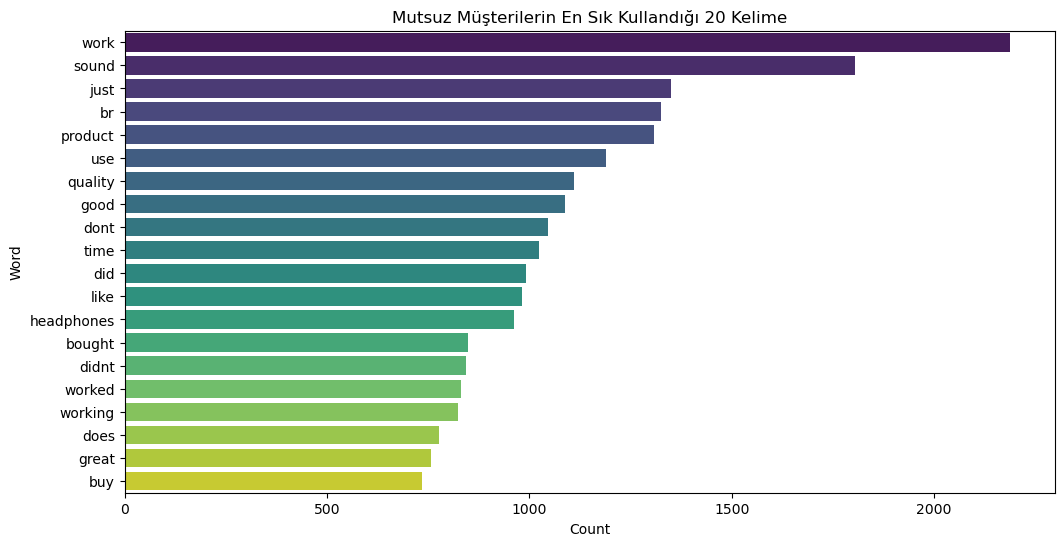

          Word  Count
0         work   2188
1        sound   1804
2         just   1349
3           br   1326
4      product   1308
5          use   1189
6      quality   1111
7         good   1088
8         dont   1045
9         time   1023
10         did    992
11        like    982
12  headphones    963
13      bought    849
14       didnt    843
15      worked    830
16     working    825
17        does    777
18       great    758
19         buy    735


In [52]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Kelime Sayıcıyı Ayarlıyoruz
vec = CountVectorizer(stop_words='english', max_features=20)

# 2. Kelimeleri Sayıyoruz (Sadece Negatiflerde)
X = vec.fit_transform(df_negative['cleaned_review'])

# 3. Sonuçları Tabloya Döküyoruz
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
words_freq = sorted(words_freq, key = lambda x: x[1], reverse=True)

df_words = pd.DataFrame(words_freq, columns=['Word', 'Count'])

# 4. Grafik Çiziyoruz
plt.figure(figsize=(12, 6))
sns.barplot(x='Count', y='Word', data=df_words, palette='viridis')
plt.title('Mutsuz Müşterilerin En Sık Kullandığı 20 Kelime')
plt.show()

print(df_words)

In [54]:
# Tüm analizi CSV dosyası olarak kaydediyoruz
df.to_csv('amazon_reviews_dashboard.csv', index=False)

print("Dosya başarıyla oluşturuldu! Klasörünü kontrol et.")

Dosya başarıyla oluşturuldu! Klasörünü kontrol et.
